# SPEX segmentation walkthrough (Patient_test_1)

Replicates the legacy segmentation workflow on `Patient_test_1.ome.tiff` using the latest SPEX build with Dask tiling enabled for all supported algorithms.

## Step 0 — Install or upgrade SPEX

In [1]:
# Uncomment if you need to install the latest SPEX build from PyPI
# !pip install -U "spex-tools

## Step 1 — Imports and image loading

In [2]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skimage import segmentation
from skimage.segmentation import mark_boundaries
from tifffile import TiffWriter, imwrite

import spex as sp

plt.rcParams["figure.dpi"] = 100

print(f"SPEX version: {sp.__version__}")

image_path = Path("Patient_test_1.ome.tiff")
if not image_path.exists():
    raise FileNotFoundError(f"File not found: {image_path}")

image_data, channel_names = sp.load_image(str(image_path))
print(f"Image shape: {image_data.shape} (C, H, W)")
print(f"Channels ({len(channel_names)}): {channel_names}")

SIMULATE_DISTANCE = 10
AUTO_TILE_SIZE = (1024, 1024)
AUTO_OVERLAP = 128

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)
_migration.py (283): `pydantic.error_wrappers:ValidationError` has been moved to `pydantic:ValidationError`.
auto.py (21): IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


SPEX version: 0.3.1055


SLF4J: No SLF4J providers were found.
SLF4J: Defaulting to no-operation (NOP) logger implementation
SLF4J: See https://www.slf4j.org/codes.html#noProviders for further details.


Image shape: (5, 14400, 17280) (C, H, W)
Channels (5): ['DAPI', 'Opal 570', 'Opal 690', 'Opal 620', 'Opal 520']


Found model '2D_versatile_fluo' for 'StarDist2D'.
Found model '2D_versatile_fluo' for 'StarDist2D'.
Found model '2D_versatile_fluo' for 'StarDist2D'.
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading network weights from 'weights_best.h5'.
Loading network weights from 'weights_best.h5'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.
Found model '2D_versatile_fluo' for 'StarDist2D'.
Found model '2D_versatile_fluo' for 'StarDist2D'.
Found model '2D_versatile_fluo' for 'StarDist2D'.
Found model '2D_versatile_fluo' for 'StarDist2

In [3]:
## Step 1a — Save/Load functions

import dill as pickle
import os
from pathlib import Path

# Create results directory
results_dir = Path("segmentation_results")
results_dir.mkdir(exist_ok=True)

def get(name):
    filename = results_dir / f"{name}.pickle"
    if filename.exists():
        with open(filename, "rb") as infile:
            return pickle.load(infile)
    return None

def put(name, data):
    filename = results_dir / f"{name}.pickle"
    with open(filename, "wb") as outfile:
        pickle.dump(data, outfile)

print(f"✅ Save/Load functions ready. Results directory: {results_dir}")


✅ Save/Load functions ready. Results directory: segmentation_results


## Step 2 — Background subtraction

In [4]:
work_image = image_data.copy()
background_channels = []  # Add channel names here if specific background channels should be removed
for channel_name in background_channels:
    if channel_name in channel_names:
        idx = channel_names.index(channel_name)
        work_image = sp.background_subtract(work_image, idx, threshold=10, subtraction=2)
        print(f"Background subtraction applied to channel: {channel_name}")
    else:
        print(f"Channel {channel_name} not found — skipping")

In [5]:
# Save work_image after preprocessing
put("work_image", work_image)
print(f"✅ Saved work_image: {work_image.shape}")


✅ Saved work_image: (5, 14400, 17280)


## Step 2a — Optional NLM denoising

In [6]:
apply_nlm = True
if apply_nlm:
    work_image = sp.nlm_denoise(work_image, patch=5, dist=6)
    print("NLM denoising applied")
else:
    print("Skipping NLM denoising")

NLM denoising applied


## Step 2b — Optional median filter

In [7]:
segmentation_channels = ["DAPI", "Opal 570", "Opal 620"]  # Adjust markers as needed
median_indices = []
for channel_name in segmentation_channels:
    if channel_name in channel_names:
        median_indices.append(channel_names.index(channel_name))
    else:
        print(f"Channel {channel_name} not found — excluding from median filter")

if median_indices:
    work_image = sp.median_denoise(work_image, kernel=4, ch=median_indices)
    print("Median denoise applied to markers:", [channel_names[i] for i in median_indices])
else:
    print("No markers available for median denoise")

Median denoise applied to markers: ['DAPI', 'Opal 570', 'Opal 620']


## Step 3 — Segmentation choices

In [8]:
merge_indices = []
for channel_name in segmentation_channels:
    if channel_name in channel_names:
        merge_indices.append(channel_names.index(channel_name))

if not merge_indices:
    raise ValueError("No segmentation markers were found; update `segmentation_channels` above.")

### Option A — StarDist (Dask)

In [9]:
stardist_labels = sp.stardist_cellseg(
    work_image,
    merge_indices,
    scaling=1,
    threshold=0.5,
    _min=1,
    _max=98.5,
)
print(f"StarDist detected {int(stardist_labels.max())} objects")

⚠️  Large number of tiles (72) may cause timeout
📊 Tiling estimate: 72 tiles, ~4.8 min, 76.3MB/tile
🧩 Dask tiling: (2000, 2000) tiles, 64px overlap
📊 Processing 72 tiles...
🚀 Auto-enabled parallel processing for 72 tiles


Processing tiles:   0%|          | 0/72 [00:00<?, ?tile/s]

🔄 Creating delayed computation graph...
🚀 Processing 72 tiles in batches of 4...


Assembling tile 72/72: 100%|██████████| 72/72 [03:12<00:00,  2.68s/tile, Memory=15801.2MB, Δ=+6076.9MB, Failed=0]


📊 Parallel processing complete: 72/72 tiles processed, 0 failed
⏱️  Total time: 192.7s, Memory: 15801.2MB
✅ Dask parallel tiling completed. Labels found: 126009
StarDist detected 132798 objects


In [10]:
# Save StarDist results
put("stardist_labels", stardist_labels)
print(f"✅ Saved StarDist: {stardist_labels.max()} objects")


✅ Saved StarDist: 132798 objects


### Option B — Cellpose (auto + Dask)

In [11]:
cellpose_labels_auto = sp.cellpose_cellseg(
    work_image,
    merge_indices,
    diameter=30,
    scaling=1.0,
)
print(f"Cellpose detected {int(cellpose_labels_auto.max())} objects")

🧩 Calculated tile size: 2048x2048 → 72 tiles total
⚠️  Large number of tiles (99) may cause timeout
📊 Tiling estimate: 99 tiles, ~6.9 min, 80.0MB/tile
🧩 Dask tiling: (2048, 2048) tiles, 409px overlap
📊 Processing 99 tiles...
🚀 Auto-enabled parallel processing for 99 tiles


Processing tiles:   0%|          | 0/99 [00:00<?, ?tile/s]

🔄 Creating delayed computation graph...
🚀 Processing 99 tiles in batches of 4...


Assembling tile 99/99: 100%|██████████| 99/99 [45:55<00:00, 27.83s/tile, Memory=27393.0MB, Δ=+11591.7MB, Failed=0]


📊 Parallel processing complete: 99/99 tiles processed, 0 failed
⏱️  Total time: 2755.2s, Memory: 27393.0MB
✅ Dask parallel tiling completed. Labels found: 8384
Cellpose detected 12191 objects


In [12]:
# Save Cellpose results
put("cellpose_labels_auto", cellpose_labels_auto)
print(f"✅ Saved Cellpose: {cellpose_labels_auto.max()} objects")


✅ Saved Cellpose: 12191 objects


### Option C — Watershed (Dask)

In [13]:
watershed_labels = sp.watershed_classic(
    work_image,
    merge_indices,
)
print(f"Watershed detected {int(watershed_labels.max())} objects")

⚠️  Large number of tiles (72) may cause timeout
📊 Tiling estimate: 72 tiles, ~4.8 min, 76.3MB/tile
🧩 Dask tiling: (2000, 2000) tiles, 64px overlap
📊 Processing 72 tiles...
🚀 Auto-enabled parallel processing for 72 tiles


Processing tiles:   0%|          | 0/72 [00:00<?, ?tile/s]

🔄 Creating delayed computation graph...
🚀 Processing 72 tiles in batches of 4...


Assembling tile 72/72: 100%|██████████| 72/72 [08:44<00:00,  7.28s/tile, Memory=27393.0MB, Δ=+0.0MB, Failed=0]


📊 Parallel processing complete: 72/72 tiles processed, 0 failed
⏱️  Total time: 524.2s, Memory: 27393.0MB
✅ Dask parallel tiling completed. Labels found: 492175
Watershed detected 518974 objects


In [14]:
# Save Watershed results
put("watershed_labels", watershed_labels)
print(f"✅ Saved Watershed: {watershed_labels.max()} objects")


✅ Saved Watershed: 518974 objects


## Step 3a — Visualisation and saving

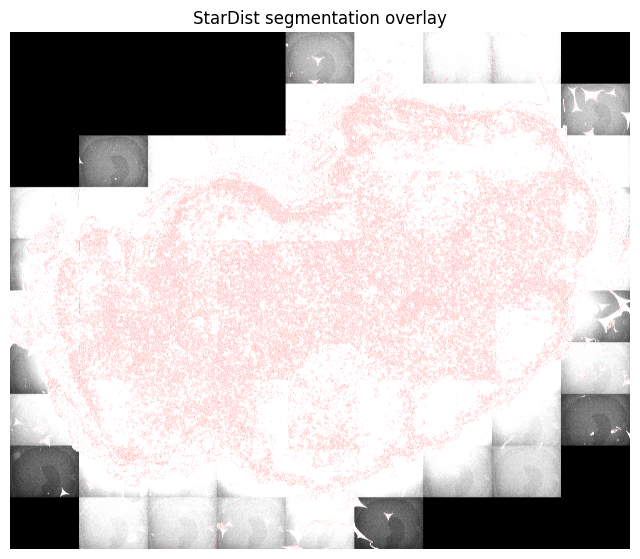

Saved StarDist labels to Patient_test_1.ome_stardist_labels.tif
Saved overlay to Patient_test_1.ome_stardist_overlay.jpg


In [15]:
base_channel = work_image[merge_indices[0]]
boundary_overlay = mark_boundaries(base_channel, stardist_labels, color=(1, 0, 0))

plt.figure(figsize=(8, 8))
plt.imshow(boundary_overlay)
plt.title("StarDist segmentation overlay")
plt.axis("off")
plt.show()

labels_path = image_path.stem + "_stardist_labels.tif"
overlay_path = image_path.stem + "_stardist_overlay.jpg"
imwrite(labels_path, stardist_labels.astype(np.uint32), photometric="minisblack")

overlay_norm = boundary_overlay.astype(np.float32)
overlay_norm -= overlay_norm.min()
max_val = overlay_norm.max()
if max_val > 0:
    overlay_norm /= max_val

plt.imsave(overlay_path, overlay_norm)
print(f"Saved StarDist labels to {labels_path}")
print(f"Saved overlay to {overlay_path}")

## Step 4 — Post-processing

In [16]:
rescued_labels = sp.rescue_cells(work_image, merge_indices, stardist_labels)
print(f"Rescued labels: {int(rescued_labels.max())} objects")

clean_labels = sp.remove_small_objects(rescued_labels, 8)
clean_labels = sp.remove_large_objects(clean_labels, 200000)
print(f"Labels after size filtering: {int(clean_labels.max())} objects")

expanded_labels = sp.simulate_cell(clean_labels, SIMULATE_DISTANCE)
print(f"Expanded labels: {int(expanded_labels.max())} objects")

Rescued labels: 255483 objects
Labels after size filtering: 255483 objects
Expanded labels: 255483 objects


In [17]:
# Save expanded labels (post-processing results)
put("expanded_labels", expanded_labels)
print(f"✅ Saved expanded: {expanded_labels.max()} objects")


✅ Saved expanded: 255483 objects


### Feature extraction

In [18]:
# Feature extraction with object limit for large datasets
# Use the direct import to avoid caching issues
features_adata = sp.feature_extraction_adata(work_image, expanded_labels, channel_names, max_objects=1000)
features_df = features_adata.to_df()

# Add coordinates from obs to df (coordinates are stored in .obs, not .X)
features_df['centroid_y'] = features_adata.obs['y_coordinate'].values
features_df['centroid_x'] = features_adata.obs['x_coordinate'].values

# Debug information
print(f'Features shape: {features_adata.X.shape}')
print(f'DataFrame columns: {list(features_df.columns)}')
print(f'Available features in .X: {features_adata.var_names.tolist()}')
features_df.head()

Filtering from 255483 to 1000 largest objects
Filtered to 1000 objects
Features shape: (1000, 5)
DataFrame columns: ['DAPI', 'Opal 570', 'Opal 690', 'Opal 620', 'Opal 520', 'centroid_y', 'centroid_x']
Available features in .X: ['DAPI', 'Opal 570', 'Opal 690', 'Opal 620', 'Opal 520']


anndata.py (121): Transforming to str index.


,DAPI,Opal 570,Opal 690,Opal 620,Opal 520,centroid_y,centroid_x
0,5.936927,4.240441,6.872557,3.901082,2.526208,14044.762575,9798.210639
1,6.707314,4.153013,7.180267,4.393292,3.067975,13831.471071,8194.538662
2,6.436703,4.236896,7.048258,3.818206,2.451317,8039.476368,16484.203388
3,5.796627,4.210421,6.352081,3.745053,2.439776,8585.449524,16105.098952
4,4.770172,3.266197,6.286048,3.439172,1.692018,1400.837055,8488.347982


In [19]:
# Save features data
put("features_adata", features_adata)
print(f"✅ Saved features: {features_adata.shape}")


✅ Saved features: (1000, 5)


## Step 5 — Optional dependency install

In [20]:
# Uncomment if you need additional plotting packages in a fresh environment
# !pip install seaborn 'scanpy<1.10'

## Step 6 — Phenotyping / clustering example

In [21]:
import pandas as pd
import scanpy as sc

print("Feature columns:", features_df.columns.tolist())
features_df['cluster_id'] = np.random.randint(1, 6, size=features_df.shape[0])
features_adata.obs['cluster_id'] = pd.Categorical(features_df['cluster_id'].astype(str))
print(features_adata.obs['cluster_id'].value_counts())

Feature columns: ['DAPI', 'Opal 570', 'Opal 690', 'Opal 620', 'Opal 520', 'centroid_y', 'centroid_x']
cluster_id
4    216
1    207
5    202
3    189
2    186
Name: count, dtype: int64


### Matrixplot and violin plots

Selected features for plotting: ['DAPI', 'Opal 570', 'Opal 690', 'Opal 620', 'Opal 520']
Available features in .X: ['DAPI', 'Opal 570', 'Opal 690', 'Opal 620', 'Opal 520']
DataFrame columns: ['DAPI', 'Opal 570', 'Opal 690', 'Opal 620', 'Opal 520', 'centroid_y', 'centroid_x', 'cluster_id']


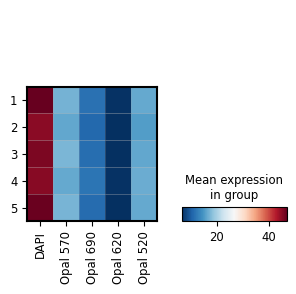

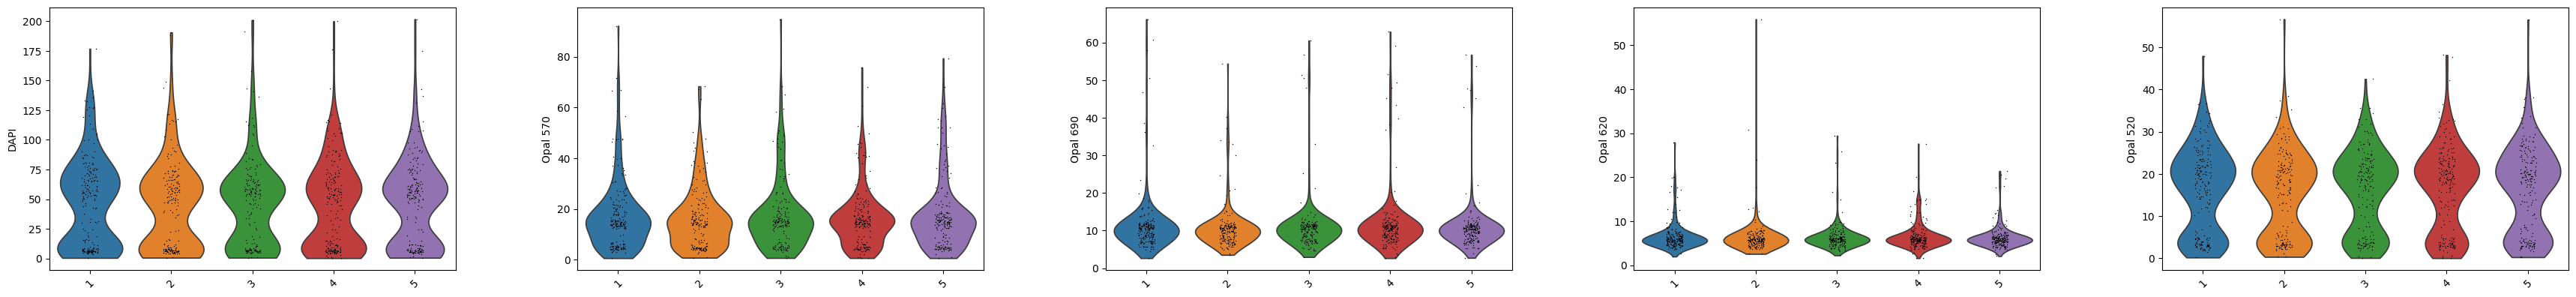

In [22]:
# Use only channel features for plotting (coordinates are in .obs, not .X)
selected_features = channel_names[:5]  # Use actual channel names

print(f'Selected features for plotting: {selected_features}')
print(f'Available features in .X: {features_adata.var_names.tolist()}')
print(f'DataFrame columns: {list(features_df.columns)}')

# These plots work with channel features that exist in features_adata.X
sc.pl.matrixplot(features_adata, selected_features, groupby='cluster_id', dendrogram=False, cmap='RdBu_r', show=False)
plt.show()

sc.pl.violin(features_adata, selected_features, groupby='cluster_id', rotation=45, show=False)
plt.show()

### UMAP projection

🔧 Preprocessing data for UMAP analysis...
Data shape: (1000, 5)
NaN values in data: 5000
⚠️  NaN values detected after log1p, replacing with 0
✅ Data ready for PCA: (1000, 5), NaN values: 0
📊 PCA components: 4 (max possible: 5, features: 5, samples: 1000)


_normalization.py (196): Some cells have zero counts
_pca.py (640): invalid value encountered in divide
scatterplots.py (391): No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored


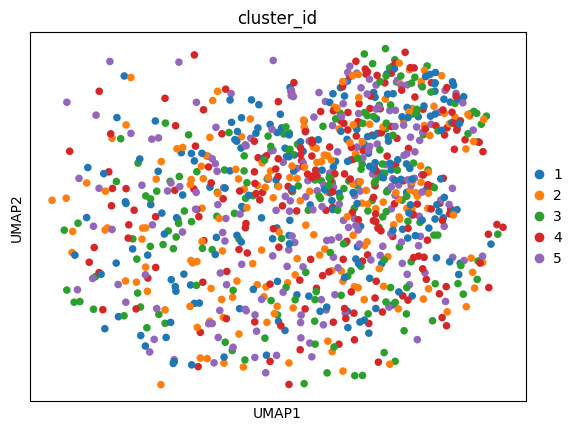

In [25]:
# Preprocessing data for UMAP analysis
print("🔧 Preprocessing data for UMAP analysis...")

# Check data shape and basic statistics
print(f"Data shape: {features_adata.X.shape}")
print(f"NaN values in data: {np.isnan(features_adata.X).sum()}")

# Standard scanpy preprocessing pipeline
sc.pp.normalize_total(features_adata, target_sum=1e4)
sc.pp.log1p(features_adata)

# Handle any NaN values that might appear after log transformation
if np.isnan(features_adata.X).any():
    print("⚠️  NaN values detected after log1p, replacing with 0")
    features_adata.X = np.nan_to_num(features_adata.X, nan=0.0, posinf=0.0, neginf=0.0)

sc.pp.scale(features_adata, max_value=10)

# Final check for NaN values before PCA
if np.isnan(features_adata.X).any():
    print("⚠️  NaN values still present after scaling, replacing with 0")
    features_adata.X = np.nan_to_num(features_adata.X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"✅ Data ready for PCA: {features_adata.X.shape}, NaN values: {np.isnan(features_adata.X).sum()}")

# Calculate appropriate number of PCA components
n_features = features_adata.X.shape[1]
n_samples = features_adata.X.shape[0]
max_possible = min(n_samples, n_features)
n_comps = min(30, max_possible - 1)

# Ensure we have at least 1 component and it's strictly less than max_possible
if n_comps <= 0:
    n_comps = max(1, max_possible - 1)

print(f"📊 PCA components: {n_comps} (max possible: {max_possible}, features: {n_features}, samples: {n_samples})")

# Standard dimensionality reduction pipeline
if n_comps > 0 and n_comps < max_possible:
    sc.tl.pca(features_adata, n_comps=n_comps)
    sc.pp.neighbors(features_adata, n_neighbors=min(10, n_samples-1), n_pcs=n_comps)
    sc.tl.umap(features_adata)
    sc.pl.umap(features_adata, color='cluster_id')
else:
    print(f"⚠️  Cannot perform PCA: need n_comps < min(samples, features) = {max_possible}")
    print("Skipping UMAP analysis - insufficient data dimensionality")

## Step 7 — Example batch processing

In [26]:
stardist_labels = sp.stardist_cellseg(
    work_image,
    merge_indices,
    scaling=1,
    threshold=0.5,
    _min=1,
    _max=98.5,
)
print(f"StarDist detected {int(stardist_labels.max())} objects")

⚠️  Large number of tiles (72) may cause timeout
📊 Tiling estimate: 72 tiles, ~4.8 min, 76.3MB/tile
🧩 Dask tiling: (2000, 2000) tiles, 64px overlap
📊 Processing 72 tiles...
🚀 Auto-enabled parallel processing for 72 tiles


Processing tiles:   0%|          | 0/72 [00:00<?, ?tile/s]

🔄 Creating delayed computation graph...
🚀 Processing 72 tiles in batches of 4...


Assembling tile 72/72: 100%|██████████| 72/72 [03:09<00:00,  2.63s/tile, Memory=41586.9MB, Δ=+291.1MB, Failed=0] 


📊 Parallel processing complete: 72/72 tiles processed, 0 failed
⏱️  Total time: 189.2s, Memory: 41586.9MB
✅ Dask parallel tiling completed. Labels found: 126009
StarDist detected 132798 objects
